In [1]:
import torch
import torch.nn as nn
import numpy as np
import sigpy as sp
from glob import glob
import sigpy.plot as spl
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import einsum, rearrange
import einops
import defaultstrategy
import math
import time
from tqdm.auto import tqdm
from gsplat.project_gaussians_2d import project_gaussians_2d

from gsplat.rasterize_sum import rasterize_gaussians_sum

from arrayview import view
import SimpleITK as sitk
%matplotlib widget

/local_scratch/mterpst5/MicroscopyMOTUS/.venv/lib/python3.13/site-packages/sigpy/config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
libcudnn.so.8: cannot open shared object file: No such file or directory
  warnings.warn(


In [2]:
datapath = '/local_scratch/mterpst5/MicroscopyMOTUS/GroundTruth.tif'

In [99]:
ground_truth_data = reference_image_np = (sitk.GetArrayFromImage(sitk.ReadImage(f'{datapath}')) / (1024)).astype(np.float32)
ground_truth_data = torch.from_numpy(rearrange(ground_truth_data, '(time slices) x y -> time x y slices', slices=11)).float()[:150, ..., 5].cuda()
timepoints, x, y = ground_truth_data.shape

In [100]:
ground_truth_data.shape

torch.Size([150, 100, 140])

In [113]:
# Assuming your external rasterization and strategy modules are imported:
# from gsplat import project_gaussians_2d, project_gaussians_2d_scale_rot, rasterize_gaussians_sum

class Config:
    prune_opa: float = 0.05
    grow_grad2d: float = 0.02
    grow_scale3d: float = 0.01
    prune_scale3d: float = 0.1
    refine_start_iter: int = 500
    refine_stop_iter: int = 15_000
    reset_every: int = 3000
    refine_every: int = 100
    absgrad: bool = False
    revised_opacity: bool = False
    key_for_gradient = "gradient_2dgs"


class GaussianImage(nn.Module):
    def __init__(self, loss_type="L2", representation='Cholesky', **kwargs):
        super().__init__()
        self.loss_type = loss_type
        self.init_num_points = kwargs["num_points"]
        self.timepoints = kwargs['timepoints']
        self.representation = representation

        self.MINIBATCH = 20  # Batch size of timeframes per iteration
        self.H, self.W = kwargs["H"], kwargs["W"]
        self.BLOCK_W, self.BLOCK_H = kwargs["BLOCK_W"], kwargs["BLOCK_H"]
        self.tile_bounds = (
            (self.W + self.BLOCK_W - 1) // self.BLOCK_W,
            (self.H + self.BLOCK_H - 1) // self.BLOCK_H,
            1,
        )
        self.device = kwargs["device"]
        
        # Initialize strategy for adaptive control (splitting/pruning)
        self.strategy = defaultstrategy.Strategy2DWithMotion(verbose=True)
        self.strategy_state = self.strategy.initialize_state()

        # Initialize spatial coordinates in [-1, 1] range via Sobol sequence
        from scipy.stats import qmc
        sampler = qmc.Sobol(d=2, scramble=True)
        points_unit_domain = sampler.random(n=self.init_num_points)
        points_scaled = -1 + points_unit_domain * 2
        self._xyz = nn.Parameter(torch.from_numpy(points_scaled).float().to(self.device))

        self.noise_params = nn.Parameter(0.001 * torch.randn(2).to(self.device))
        # Motion vectors over time
        self._motionvecs = nn.Parameter(torch.zeros(self.init_num_points, 2, self.timepoints))
        
        if self.representation.lower() == 'cholesky':
            self._cholesky = nn.Parameter(torch.rand(self.init_num_points, 3))
            self._choleskytime = nn.Parameter(torch.zeros(self.init_num_points, 3, self.timepoints))
        else:
            self._rotation = nn.Parameter(torch.rand(self.init_num_points, 1))
            self._scaling = nn.Parameter(torch.rand(self.init_num_points, 2))
            self.rotation_activation = torch.sigmoid
            
        self._opacity = nn.Parameter(torch.ones((self.init_num_points,)))
        
        # Grayscale image space needs 1 feature channel instead of 2
        self._features_dc = nn.Parameter(torch.zeros(self.init_num_points, 1))
        
        self.background = torch.zeros(1, device=self.device)  # Grayscale background
        self.opacity_activation = torch.sigmoid
        self.rgb_activation = F.softplus
        
        self.register_buffer('bound', torch.tensor([0.5, 0.5]).view(1, 2))
        self.register_buffer('cholesky_bound', torch.tensor([0.5, 0, 0.5]).view(1, 3))

        print(kwargs["opt_type"] )
        if kwargs["opt_type"] == "adam":
            self.optimizer = torch.optim.Adam(self.parameters(), lr=kwargs["lr"])
        elif kwargs["opt_type"] == "sgd":
            self.optimizer = torch.optim.SGD(self.parameters(), lr=kwargs["lr"])

        else:
            self.optimizer = Lion(self.parameters(), lr=kwargs["lr"])
            
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=1500, gamma=0.6)

    def get_xyz(self, t, motion=True):
        if motion:
            return torch.tanh(self._xyz + self._motionvecs[..., t].squeeze())
        else:
            return torch.tanh(self._xyz)
    
    @property
    def get_features(self):
        # Pass features through the activation function to keep outputs bounded
        return self.rgb_activation(self._features_dc)
    
    def get_opacity(self, t, motion=True):
        return self.opacity_activation(self._opacity)

    def get_cholesky_elements(self, t, motion=True):
        if False:
            return self._cholesky + self._choleskytime[..., t].squeeze() + self.cholesky_bound
        else:
            return self._cholesky + self.cholesky_bound
    
    def get_scaling(self, t):
        return torch.abs(self._scaling + self.bound)
    
    def get_rotation(self, t):
        return self.rotation_activation(self._rotation) * 2 * math.pi
    
    def forward(self, t, motion=True):
        if self.representation.lower() == 'cholesky':
            self.xys, depths, self.radii, conics, num_tiles_hit = project_gaussians_2d(
                self.get_xyz(t, motion=motion), 
                self.get_cholesky_elements(t, motion=motion), 
                self.H, self.W, self.tile_bounds
            )
        else:
            self.xys, depths, self.radii, conics, num_tiles_hit = project_gaussians_2d_scale_rot(
                self.get_xyz(t, motion=motion), 
                self.get_scaling(t), 
                self.get_rotation(t), 
                self.H, self.W, self.tile_bounds
            )
            
        out_img = rasterize_gaussians_sum(
            self.xys, depths, self.radii, conics, num_tiles_hit,
            self.get_features, 
            self.get_opacity(t, motion=motion).squeeze().unsqueeze(-1), 
            self.H, self.W, self.BLOCK_H, self.BLOCK_W, 
            background=self.background, return_alpha=False
        )
        
        out_img += torch.randn_like(out_img) * self.noise_params[0] + self.noise_params[1]

        
        # Squeeze the trailing channel dimension to match target shape (H, W)
        return {"render": out_img.squeeze(-1), "points": self.get_xyz(t, motion=motion)}

    def save_gaussian_visualizations(self, dic, base_storage_folder, iteration):
        alpha_dir = os.path.join(base_storage_folder, "output_fig", "alpha")
        noalpha_dir = os.path.join(base_storage_folder, "output_fig", "noalpha")

        os.makedirs(alpha_dir, exist_ok=True)
        os.makedirs(noalpha_dir, exist_ok=True)

        display_iter = iteration - 1

        out_img = dic['render'].detach().abs()
        norm_img = 255 * (out_img / torch.quantile(out_img, 0.95).clamp(min=1e-5))
        norm_img = norm_img.clamp(0, 255).cpu().numpy().astype(np.uint8)

        my_image_alpha = Image.fromarray(norm_img).convert('L')
        draw_alpha = ImageDraw.Draw(my_image_alpha)
        text_str = f"{display_iter}/5000"
        draw_alpha.text((10, 10), text_str, fill=255, font_size=16, align="left")
        my_image_alpha.save(os.path.join(alpha_dir, f'{display_iter}.png'))

        # Scatter Plot mapping [-1, 1] parameters back to raw pixel dimensions
        scatter_points = dic['points'].detach().cpu()
        img_h, img_w = norm_img.shape[0], norm_img.shape[1]

        def remap_point(point, width, height):
            y_norm, x_norm = point
            x_pixel = int(((x_norm + 1) / 2) * (width - 1))
            y_pixel = int(((-y_norm + 1) / 2) * (height - 1))
            return (x_pixel, y_pixel)

        pixel_points = [
            remap_point(scatter_points[i, :], img_w, img_h) 
            for i in range(scatter_points.shape[0])
        ]

        my_image_scatter = Image.new('RGB', (img_w, img_h), color='black')
        draw_scatter = ImageDraw.Draw(my_image_scatter)
        draw_scatter.point(pixel_points, fill='white')
        draw_scatter.text((10, 10), text_str, fill=(255, 255, 255), font_size=16, align="left")
        my_image_scatter.save(os.path.join(noalpha_dir, f'{display_iter}.png'))
        
    @torch.no_grad()
    def initialize_unseen_timepoints_from_anchors(self, target_slices, num_anchors=50):
        """
        Evaluates the first `num_anchors` timepoints against all timepoints in target_slices.
        Copies the motion parameters of the lowest-error anchor to each unseen timepoint.
        """
        print(f"\n--- Initializing remaining {self.timepoints - num_anchors} timepoints from top-performing anchors ---")
        self.eval()
        
        anchor_slices = target_slices[:num_anchors]

        # Step 2: Match every absolute timeline index to the best anchor frame
        for t_target in range(target_slices.shape[0]):
            # Skip the anchors themselves
            if t_target < num_anchors:
                continue

            # Get the actual ground-truth 1D slice for this target timepoint
            gt_slice = target_slices[t_target] # Shape: (W,)

            # Compute L2 error against all 50 cached anchor profiles
            # Broadcasts to (num_anchors, W) -> sum over width dimension
            errors = torch.mean((anchor_slices.reshape(num_anchors, -1) - gt_slice.unsqueeze(0).reshape(1, -1)) ** 2, dim=-1)
            
            best_anchor_idx = torch.argmin(errors).item()

            # Step 3: Copy the dynamic parameters from the best matching anchor
            self._motionvecs.data[..., t_target] = self._motionvecs.data[..., best_anchor_idx]

            if self.representation.lower() == 'cholesky':
                self._choleskytime.data[..., t_target] = self._choleskytime.data[..., best_anchor_idx]

        print("Parameter broadcast complete.")
        self.train()
    
    def train_iter(self, iter, target_tensor, generate_image=False, generate_image_path=None):
        """
        Args:
            target_tensor (torch.Tensor): Grayscale target tensor of shape (timepoints, H, W)
        """
        # Batch random time frames for reconstruction
#         T = torch.randint(low=0, high=self.timepoints, size=(self.MINIBATCH,)) if iter > 1000 else torch.randint(low=0, high=50, size=(self.MINIBATCH,))
        
        samples = torch.arange(self.timepoints) if iter > 1000 else torch.arange(50)
        shuffled_indices = torch.randperm(len(samples))
        x_shuffled = samples[shuffled_indices]
        chunks = torch.split(x_shuffled, self.MINIBATCH)

        if iter == 1000:
            # Run the parameter cloning routine directly using the target tensor data
            self.initialize_unseen_timepoints_from_anchors(
                target_slices=target_tensor, 
                num_anchors=50
            )
        
        mses, psnrs = 0.0, 0.0
        loss = 0.0

        for T in chunks:
            for t in T:
                t_idx = t.item()
                if iter < 100:
                    render_pkg = self.forward(0, motion=False)
                    target_image = target_tensor[0]


                else:
                    render_pkg = self.forward(t_idx, motion=True)
                    target_image = target_tensor[t_idx]

                rendered_image = render_pkg["render"] 



    #             if t_idx == 0 and (iter - 1) % 10 == 0 and generate_image and generate_image_path is not None:
    #                 self.save_gaussian_visualizations(render_pkg, generate_image_path, iter)

                # Direct image space loss calculation
                if self.loss_type == "L1":
                    loss_frame = torch.abs(rendered_image - target_image).mean()
                else:  # L2 Loss
                    loss_frame = torch.mean((rendered_image - target_image) ** 2)

                loss += loss_frame / len(samples)

                with torch.no_grad():
                    mse_val = torch.mean((rendered_image - target_image) ** 2)
                    mses += mse_val / len(samples)
                    psnr_val = 10 * math.log10(1.0 / (mse_val.item() + 1e-10))
                    psnrs += psnr_val / len(samples)

        # Regulate motion vector smoothness and rank
        reg_dvfrank = torch.linalg.norm(einops.rearrange(torch.tanh(self._motionvecs), 'space dim time -> (space dim) time'), "nuc")
        reg_tv_dvf = torch.linalg.vector_norm(torch.diff(torch.tanh(self._motionvecs), dim=-1), ord=1)
        reg_tv_cholesky = torch.linalg.vector_norm(torch.diff(self._choleskytime, dim=-1), ord=1)

        scale_violations = torch.clamp(0.4 - self.get_features, min=0.0)
        scale_loss = torch.mean(scale_violations ** 2)
        
        total_loss = loss + scale_loss + 0.000001 * reg_dvfrank + 0.000001 * reg_tv_dvf + 0.00001 * reg_tv_cholesky
        
        total_loss.backward()
        
        info = {'height': self.H, 'width': self.W}
        
        # Build adaptive strategy tracking dictionary
        if self.representation.lower() == 'cholesky':
            params_dict = {
                '_xyz': self._xyz, 
                '_motionvecs': self._motionvecs,
                '_cholesky': self._cholesky, 
                '_choleskytime': self._choleskytime, 
                '_opacity': self._opacity, 
                '_features_dc': self._features_dc,
                'choleskybound': self.cholesky_bound
            }
        else:
            params_dict = {
                '_xyz': self._xyz, 
                '_motionvecs': self._motionvecs,
                '_scaling': self._scaling, 
                '_rotation': self._rotation,
                '_opacity': self._opacity, 
                '_features_dc': self._features_dc
            }

        # Apply splitting, pruning, and cloning strategies
#         self.strategy.step_post_backward(params_dict, self.optimizer, self.strategy_state, iter, info)
        
        # Reassign potentially modified variables from splitting/pruning
        self._xyz = params_dict["_xyz"]
        if self.representation.lower() == 'cholesky':
            self._cholesky = params_dict["_cholesky"]
            self._choleskytime = params_dict['_choleskytime']
        else:
            self._scaling = params_dict['_scaling']
            self._rotation = params_dict['_rotation']

        self._features_dc = params_dict["_features_dc"]
        self._opacity = params_dict["_opacity"]
        self._motionvecs = params_dict['_motionvecs']
        
        self.optimizer.step()
        self.optimizer.zero_grad(set_to_none=True)
        self.scheduler.step()
        
        return mses, psnrs

class MotionTrainer2d:
    """Trains 2D Gaussians with motion models to fit a target 2D+t image sequence directly in image space."""
    def __init__(
        self,
        target_tensor: torch.Tensor,  # Shape: (timepoints, H, W)
        num_points: int = 5000,
        model_name: str = "GaussianImage_Cholesky",
        iterations: int = 5000,
        lr: float = 1e-2,
        model_path = None,
        args = None,
    ):
        self.device = torch.device("cuda:0")
        
        # Ensure target tensor is on the correct device
        self.target_tensor = target_tensor.to(self.device)
        
        # Pull dimensions directly from the target [T, H, W] image tensor
        self.timepoints = self.target_tensor.shape[0]
        self.H, self.W = self.target_tensor.shape[1], self.target_tensor.shape[2]

        self.num_points = num_points
        BLOCK_H, BLOCK_W = 16, 16
        self.iterations = iterations
        
        self.gaussian_model = GaussianImage(
            loss_type="L1", 
            representation='cholesky',
            opt_type="adam", 
            num_points=self.num_points, 
            timepoints=self.timepoints,
            H=self.H, W=self.W, 
            BLOCK_H=BLOCK_H, BLOCK_W=BLOCK_W, 
            device=self.device, lr=lr, quantize=False
        ).to(self.device)
        
    def train(self, generate_image=False, generate_image_path=None):     
        psnr_list, iter_list = [], []
        progress_bar = tqdm(range(1, self.iterations+1), desc="Training progress")
        self.gaussian_model.train()
        start_time = time.time()
        
        for iter in range(1, self.iterations+1):
            # Pass target_tensor directly to the image-space train step
            loss, psnr = self.gaussian_model.train_iter(
                iter, 
                target_tensor=self.target_tensor,
                generate_image=generate_image, 
                generate_image_path=generate_image_path
            )
            psnr_list.append(psnr)
            iter_list.append(iter)
            
            with torch.no_grad():
                if iter % 10 == 0:
                    progress_bar.set_postfix({
                        "Loss": f"{loss.item():.{7}f}", 
                        "PSNR": f"{psnr:.{4}f}"
                    })
                    progress_bar.update(10)
                    
        end_time = time.time() - start_time
        progress_bar.close()
        
        if generate_image and generate_image_path is not None:
            # Assuming create_gif is imported/defined elsewhere
            create_gif(os.path.join(generate_image_path, "output_fig", "noalpha"))
            create_gif(os.path.join(generate_image_path, "output_fig", "alpha"))

    def get_images(self):
        self.gaussian_model.eval()
        imgs = []
        with torch.no_grad():
            for t in range(self.timepoints):
                # The adapted GaussianImage forward pass doesn't require complex scaling anymore
                out = self.gaussian_model(t, motion=True)['render']
                imgs.append(out)
                
        return torch.stack(imgs)

In [116]:
model = MotionTrainer2d(target_tensor=(ground_truth_data).float())
model.train()

adam


/tmp/ipykernel_1234192/3078437641.py:43: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points_unit_domain = sampler.random(n=self.init_num_points)


Training progress:   0%|          | 0/5000 [00:00<?, ?it/s]


--- Initializing remaining 100 timepoints from top-performing anchors ---
Parameter broadcast complete.


KeyboardInterrupt: 

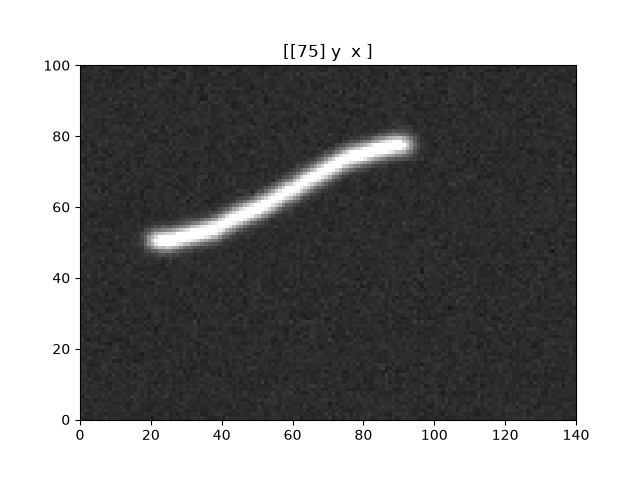

In [117]:
spl.ImagePlot(ground_truth_data.cpu().detach().numpy(), vmin=0, vmax=torch.quantile(ground_truth_data, 0.99))

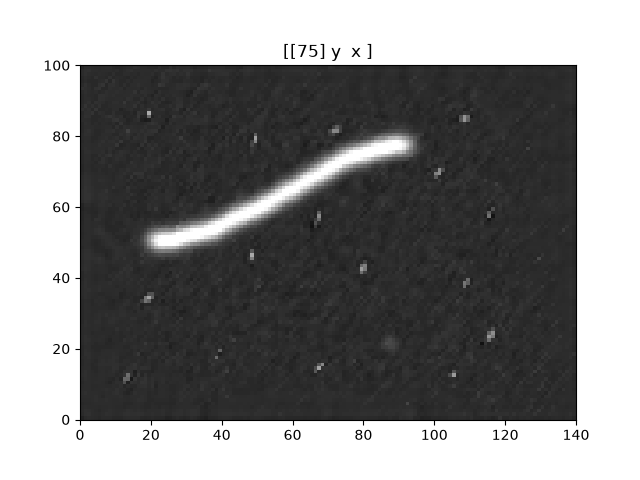

In [118]:
spl.ImagePlot(model.get_images().cpu().detach().numpy(), vmin=0, vmax=torch.quantile(ground_truth_data, 0.99))

In [120]:
print(model.gaussian_model.get_features)

tensor([[0.4041],
        [0.4005],
        [0.4045],
        ...,
        [0.6931],
        [0.6931],
        [0.6931]], device='cuda:0', grad_fn=<SoftplusBackward0>)
